In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, root_mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    mean_absolute_error,          # MAE  : erreur absolue moyenne (en années)
    mean_squared_error,           # MSE  : erreur quadratique moyenne
    root_mean_squared_error,      # RMSE : racine de MSE (en années)
    r2_score,                     # R²   : variance expliquée (0 à 1)
    mean_absolute_percentage_error # MAPE : erreur relative en %
)

In [20]:
donnees_arbre = pd.read_csv("Données_V4.csv", sep=';')

print(donnees_arbre.shape)       # Voir les premières lignes       # Types de colonnes, valeurs manquantes
print(donnees_arbre[['tronc_diam', 'age_estim']].describe())    # Statistiques de base

(11248, 36)
         tronc_diam    age_estim
count  11222.000000  10415.00000
mean      95.499644     31.37494
std       57.271243     20.35615
min        0.000000      0.00000
25%       50.000000     15.00000
50%       90.000000     30.00000
75%      131.000000     45.00000
max      565.000000    200.00000


In [21]:
# Garder uniquement les arbres en place avec des valeurs valides
donnees_arbre_clean = donnees_arbre[donnees_arbre['fk_arb_etat'] == 'EN PLACE'].copy()
donnees_arbre_clean = donnees_arbre_clean[
    (donnees_arbre_clean['tronc_diam'] > 0) &
    (donnees_arbre_clean['age_estim'] > 0)
]

print("Arbres valides :", len(donnees_arbre_clean))  

Arbres valides : 9393


In [22]:
X = donnees_arbre_clean[['tronc_diam']]  # Double crochet pour garder un DataFrame
y = donnees_arbre_clean['age_estim']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train :", len(X_train), "| Test :", len(X_test))

Train : 7514 | Test : 1879


In [23]:
model = LinearRegression()
model.fit(X_train, y_train)

print("Coefficient (pente) :", round(model.coef_[0], 3))
print("Intercept :", round(model.intercept_, 3))

Coefficient (pente) : 0.272
Intercept : 4.108


In [24]:
y_pred = model.predict(X_test)

rmse = root_mean_squared_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)

print(f"RMSE : {rmse:.2f} ans")
print(f"R²   : {r2:.3f}")

RMSE : 12.85 ans
R²   : 0.583


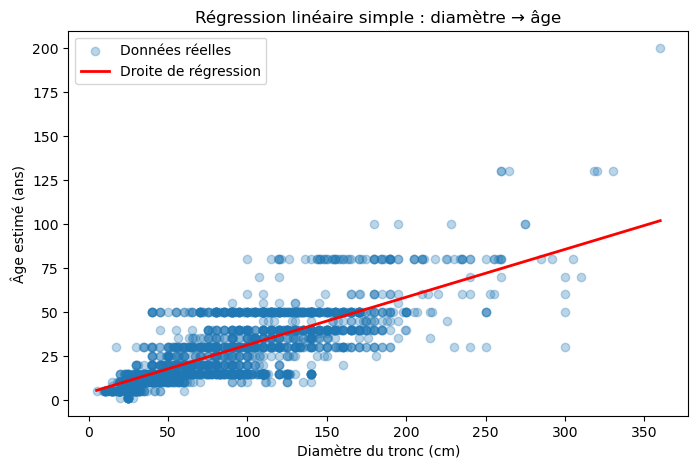

In [25]:
plt.figure(figsize=(8, 5))
plt.scatter(X_test, y_test, alpha=0.3, label="Données réelles")
plt.plot(X_test.sort_values('tronc_diam'),
         model.predict(X_test.sort_values('tronc_diam')),
         color='red', linewidth=2, label="Droite de régression")
plt.xlabel("Diamètre du tronc (cm)")
plt.ylabel("Âge estimé (ans)")
plt.title("Régression linéaire simple : diamètre → âge")
plt.legend()
plt.show()

=== Random Forest ===
RMSE : 12.78 ans
R²   : 0.588

=== Comparaison ===
Modèle                        RMSE       R²
-------------------------------------------
Régression linéaire          12.85    0.583
Random Forest                12.78    0.588


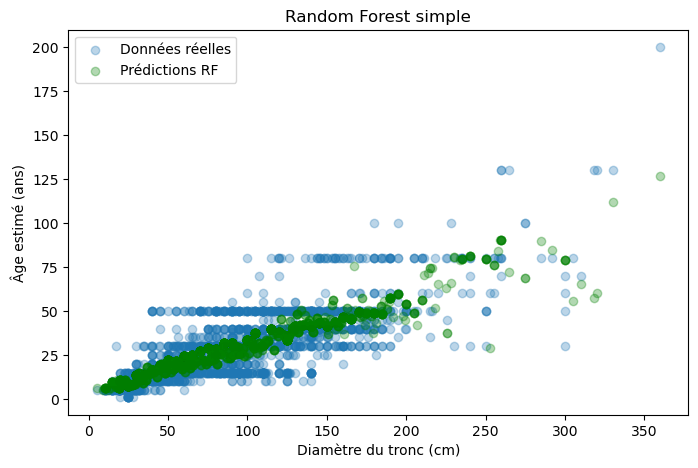


Importance de 'tronc_diam' : 1.000


In [26]:
from sklearn.ensemble import RandomForestRegressor

# --- Modèle Random Forest ---
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

rmse_rf = root_mean_squared_error(y_test, y_pred_rf)
r2_rf   = r2_score(y_test, y_pred_rf)

print("=== Random Forest ===")
print(f"RMSE : {rmse_rf:.2f} ans")
print(f"R²   : {r2_rf:.3f}")

# --- Comparaison avec la régression linéaire ---
print("\n=== Comparaison ===")
print(f"{'Modèle':<25} {'RMSE':>8} {'R²':>8}")
print("-" * 43)
print(f"{'Régression linéaire':<25} {rmse:>8.2f} {r2:>8.3f}")
print(f"{'Random Forest':<25} {rmse_rf:>8.2f} {r2_rf:>8.3f}")

# --- Graphique Random Forest ---
plt.figure(figsize=(8, 5))
plt.scatter(X_test, y_test, alpha=0.3, label="Données réelles")
plt.scatter(X_test, y_pred_rf, alpha=0.3, color='green', label="Prédictions RF")
plt.xlabel("Diamètre du tronc (cm)")
plt.ylabel("Âge estimé (ans)")
plt.title("Random Forest simple")
plt.legend()
plt.show()

# --- Importance des variables (utile si tu ajoutes d'autres features plus tard) ---
importances = rf_model.feature_importances_
print(f"\nImportance de 'tronc_diam' : {importances[0]:.3f}")

In [27]:
# PARTIE 2 — MODÈLES MULTI-FEATURES
# On réentraîne Régression Linéaire et Random Forest
# en utilisant plusieurs colonnes en entrée (au lieu de tronc_diam seul)
# pour voir si les performances s'améliorent.
# ============================================================

from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

In [28]:
features_num = ['tronc_diam', 'haut_tot', 'haut_tronc', 'clc_nbr_diag']
features_cat = ['fk_stadedev', 'fk_situation', 'fk_port', 'fk_pied', 'remarquable', 'feuillage']

# On repart du dataset nettoyé (arbres EN PLACE avec valeurs valides)
# déjà créé plus haut sous le nom donnees_arbre_clean
df_multi = donnees_arbre_clean[features_num + features_cat + ['age_estim']].copy()

print(f"Dataset multi-features : {df_multi.shape[0]} arbres, {len(features_num + features_cat)} features")
print(f"\nFeatures numériques : {features_num}")
print(f"Features catégorielles : {features_cat}")

Dataset multi-features : 9393 arbres, 10 features

Features numériques : ['tronc_diam', 'haut_tot', 'haut_tronc', 'clc_nbr_diag']
Features catégorielles : ['fk_stadedev', 'fk_situation', 'fk_port', 'fk_pied', 'remarquable', 'feuillage']


In [29]:
# Preprocessing via Pipeline sklearn
#
# On utilise un ColumnTransformer pour appliquer des transformations
# différentes selon le type de colonne :
#
#   • Colonnes numériques :
#       - SimpleImputer(median)  → remplace les NaN par la médiane de la colonne
#       - StandardScaler         → centre/réduit (moyenne=0, écart-type=1)
#
#   • Colonnes catégorielles :
#       - SimpleImputer(most_frequent) → remplace les NaN par la valeur la plus fréquente
#       - OneHotEncoder                → transforme chaque catégorie en colonne 0/1
#         Ex: fk_stadedev → [Jeune, Adulte, Vieux, Senescent] = 4 colonnes binaires
# ------------------------------------------------------------

preprocessor = ColumnTransformer(transformers=[
    ('num',
     Pipeline([
         ('imputer', SimpleImputer(strategy='median')),
         ('scaler', StandardScaler())
     ]),
     features_num),

    ('cat',
     Pipeline([
         ('imputer', SimpleImputer(strategy='most_frequent')),
         ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
     ]),
     features_cat)
])

In [30]:
# Séparation X / y et Train / Test split
# On supprime d'abord les lignes où age_estim est manquant (la cible)
# puis on sépare 80% pour l'entraînement et 20% pour l'évaluation.
# ------------------------------------------------------------

df_multi = df_multi.dropna(subset=['age_estim'])

X_multi = df_multi[features_num + features_cat]
y_multi = df_multi['age_estim']

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_multi, y_multi, test_size=0.2, random_state=42
)

print(f"\nTrain : {len(X_train_m)} arbres | Test : {len(X_test_m)} arbres")


Train : 7514 arbres | Test : 1879 arbres


In [31]:
# Régression Linéaire multi-features
#
# On encapsule le preprocessor + le modèle dans un seul Pipeline.
# Avantage : fit() et predict() appliquent automatiquement
# le preprocessing, sans risque de fuite de données (data leakage).
# ------------------------------------------------------------

pipeline_lr = Pipeline([
    ('preprocessing', preprocessor),
    ('modele', LinearRegression())
])

pipeline_lr.fit(X_train_m, y_train_m)
y_pred_lr_m = pipeline_lr.predict(X_test_m)

rmse_lr_m = root_mean_squared_error(y_test_m, y_pred_lr_m)
r2_lr_m   = r2_score(y_test_m, y_pred_lr_m)

print("\n=== Régression Linéaire — Multi-features ===")
print(f"RMSE : {rmse_lr_m:.2f} ans")
print(f"R²   : {r2_lr_m:.3f}")


=== Régression Linéaire — Multi-features ===
RMSE : 9.65 ans
R²   : 0.765


In [32]:
# Random Forest multi-features
# Même logique : Pipeline preprocessor + RandomForest.
# Le Random Forest gère bien les relations non-linéaires,
# ce qui devrait lui donner un avantage sur la régression linéaire.
# ------------------------------------------------------------

pipeline_rf = Pipeline([
    ('preprocessing', preprocessor),
    ('modele', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))
])

pipeline_rf.fit(X_train_m, y_train_m)
y_pred_rf_m = pipeline_rf.predict(X_test_m)

rmse_rf_m = root_mean_squared_error(y_test_m, y_pred_rf_m)
r2_rf_m   = r2_score(y_test_m, y_pred_rf_m)

print("\n=== Random Forest — Multi-features ===")
print(f"RMSE : {rmse_rf_m:.2f} ans")
print(f"R²   : {r2_rf_m:.3f}")


=== Random Forest — Multi-features ===
RMSE : 7.58 ans
R²   : 0.855


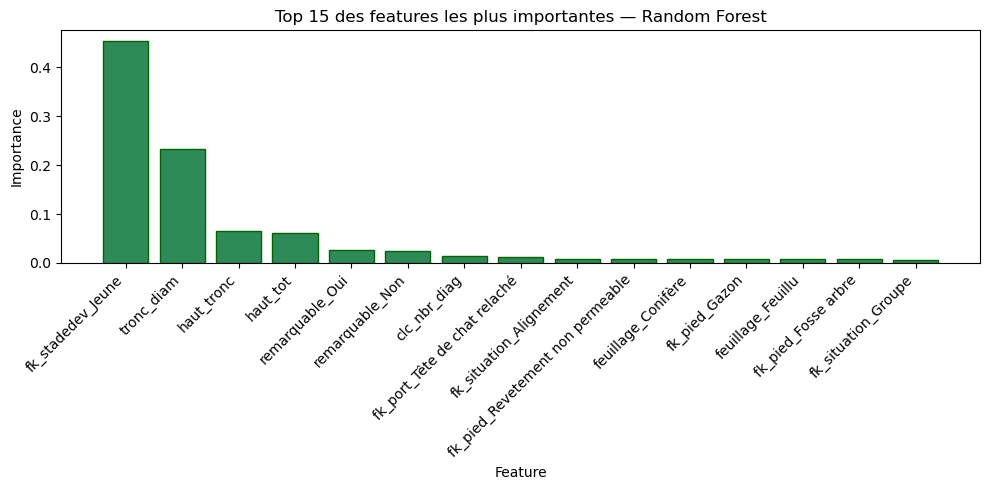

In [33]:
# Importance des features pour randon forest multi-features
#
# Le Random Forest calcule l'importance de chaque feature :
# plus une variable est utilisée pour faire des splits dans les arbres,
# plus son importance est élevée.
# Cela nous permet de savoir quelles colonnes influencent le plus l'âge.
# ------------------------------------------------------------

# Récupérer les noms des features après OneHotEncoding
noms_cat = pipeline_rf.named_steps['preprocessing'] \
               .named_transformers_['cat'] \
               .named_steps['encoder'] \
               .get_feature_names_out(features_cat)
noms_features = features_num + list(noms_cat)

importances = pipeline_rf.named_steps['modele'].feature_importances_

# Trier par importance décroissante et garder le top 15
indices = np.argsort(importances)[::-1][:15]

plt.figure(figsize=(10, 5))
plt.bar(range(15), importances[indices], color='seagreen', edgecolor='darkgreen')
plt.xticks(range(15), [noms_features[i] for i in indices], rotation=45, ha='right')
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.title("Top 15 des features les plus importantes — Random Forest")
plt.tight_layout()
plt.show()

  MAE   : 4.02 ans     (erreur absolue moyenne)
  MSE   : 57.53          (erreur quadratique moyenne)
  RMSE  : 7.58 ans     (racine de MSE)
  R²    : 0.8549          (variance expliquée)
  MAPE  : 13.92 %         (erreur relative moyenne)


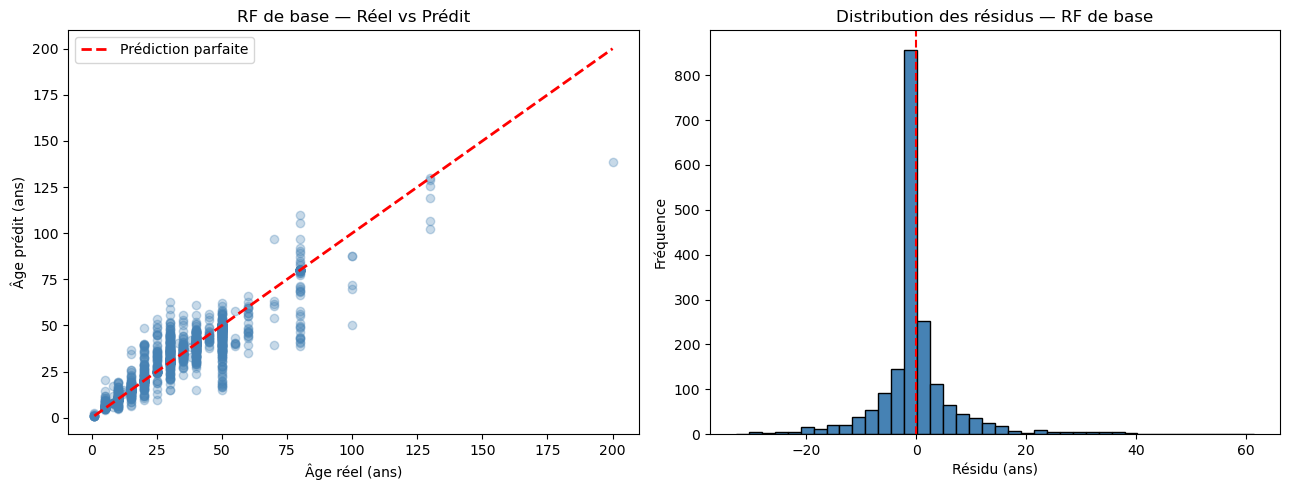

In [34]:
# On réutilise pipeline_rf et y_pred_rf_m déjà calculés en Partie 4
mae_base  = mean_absolute_error(y_test_m, y_pred_rf_m)
mse_base  = mean_squared_error(y_test_m, y_pred_rf_m)
rmse_base = root_mean_squared_error(y_test_m, y_pred_rf_m)
r2_base   = r2_score(y_test_m, y_pred_rf_m)
mape_base = mean_absolute_percentage_error(y_test_m, y_pred_rf_m)

print(f"  MAE   : {mae_base:.2f} ans     (erreur absolue moyenne)")
print(f"  MSE   : {mse_base:.2f}          (erreur quadratique moyenne)")
print(f"  RMSE  : {rmse_base:.2f} ans     (racine de MSE)")
print(f"  R²    : {r2_base:.4f}          (variance expliquée)")
print(f"  MAPE  : {mape_base*100:.2f} %         (erreur relative moyenne)")

# Graphique résidus
residus_base = y_test_m - y_pred_rf_m

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(y_test_m, y_pred_rf_m, alpha=0.3, color='steelblue')
axes[0].plot([y_test_m.min(), y_test_m.max()], [y_test_m.min(), y_test_m.max()],
             'r--', linewidth=2, label='Prédiction parfaite')
axes[0].set_xlabel("Âge réel (ans)")
axes[0].set_ylabel("Âge prédit (ans)")
axes[0].set_title("RF de base — Réel vs Prédit")
axes[0].legend()

axes[1].hist(residus_base, bins=40, color='steelblue', edgecolor='black')
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_xlabel("Résidu (ans)")
axes[1].set_ylabel("Fréquence")
axes[1].set_title("Distribution des résidus — RF de base")

plt.tight_layout()
plt.show()

In [35]:
# Grille des hyperparamètres
# Préfixe 'modele__' car les hyperparamètres sont dans le Pipeline
param_grid = {
    'modele__n_estimators'     : [100, 200, 300],
    'modele__max_depth'        : [None, 10, 20],
    'modele__min_samples_split': [2, 5, 10],
    'modele__min_samples_leaf' : [1, 2, 4],
    'modele__max_features'     : ['sqrt', 'log2']
}

nb_combinaisons = 1
for v in param_grid.values():
    nb_combinaisons *= len(v)
print(f"Nombre de combinaisons à tester : {nb_combinaisons}")
print(f"Nombre total d'entraînements    : {nb_combinaisons * 5}  (× 5 folds CV)")

Nombre de combinaisons à tester : 162
Nombre total d'entraînements    : 810  (× 5 folds CV)


In [ ]:
# On repart du même pipeline que la Partie 4 (pipeline_rf)
# mais on crée un nouveau pipeline pour ne pas modifier pipeline_rf
pipeline_gs = Pipeline([
    ('preprocessing', preprocessor),
    ('modele', RandomForestRegressor(random_state=42, n_jobs=-1))
])

# GridSearchCV
# - scoring='neg_root_mean_squared_error' : sklearn minimise, donc on utilise le négatif du RMSE
# - cv=5    : validation croisée à 5 plis
# - refit=True : réentraîne automatiquement le meilleur modèle sur tout X_train_m
grid_search = GridSearchCV(
    estimator=pipeline_gs,
    param_grid=param_grid,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    refit=True,
    verbose=2,
    return_train_score=True
)

print("Lancement du GridSearchCV...")
grid_search.fit(X_train_m, y_train_m)

print(" MEILLEURS HYPERPARAMÈTRES TROUVÉS    ")
for param, val in grid_search.best_params_.items():
    print(f"  {param:<35} : {val}")
print(f"\n  RMSE moyen (CV 5 folds) : {-grid_search.best_score_:.2f} ans")

Lancement du GridSearchCV...
Fitting 5 folds for each of 162 candidates, totalling 810 fits

══════════════════════════════════════
 MEILLEURS HYPERPARAMÈTRES TROUVÉS    
══════════════════════════════════════
  modele__max_depth                   : 20
  modele__max_features                : log2
  modele__min_samples_leaf            : 1
  modele__min_samples_split           : 2
  modele__n_estimators                : 200

  RMSE moyen (CV 5 folds) : 7.51 ans


 Random Forest OPTIMISÉ — Métriques          
  MAE   : 3.95 ans
  MSE   : 56.32
  RMSE  : 7.50 ans
  R²    : 0.8579
  MAPE  : 13.64 %


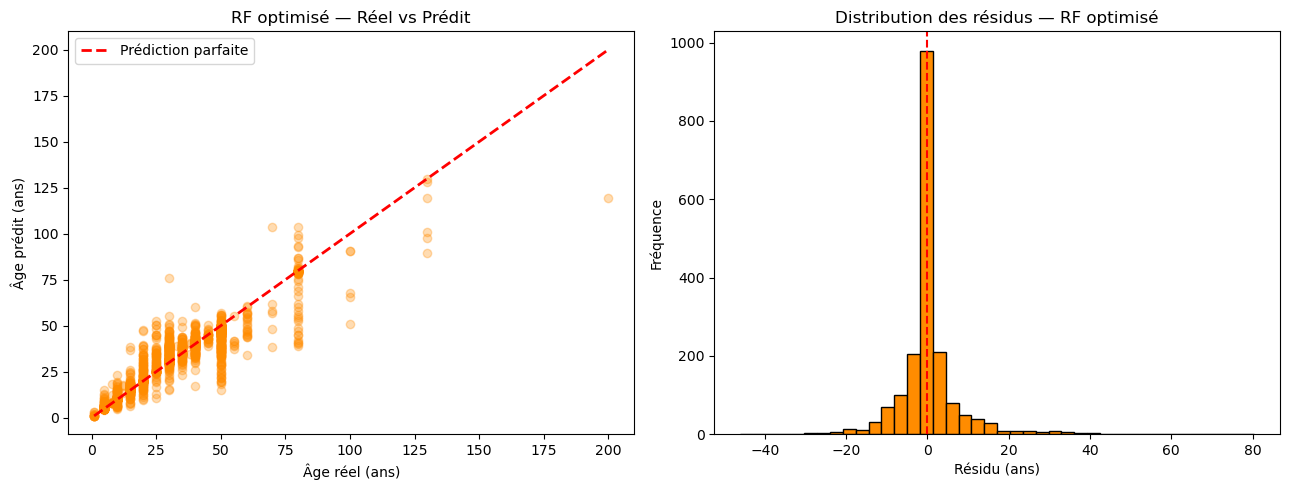

In [37]:
best_pipeline = grid_search.best_estimator_
y_pred_best   = best_pipeline.predict(X_test_m)

mae_best  = mean_absolute_error(y_test_m, y_pred_best)
mse_best  = mean_squared_error(y_test_m, y_pred_best)
rmse_best = root_mean_squared_error(y_test_m, y_pred_best)
r2_best   = r2_score(y_test_m, y_pred_best)
mape_best = mean_absolute_percentage_error(y_test_m, y_pred_best)

print(" Random Forest OPTIMISÉ — Métriques          ")
print(f"  MAE   : {mae_best:.2f} ans")
print(f"  MSE   : {mse_best:.2f}")
print(f"  RMSE  : {rmse_best:.2f} ans")
print(f"  R²    : {r2_best:.4f}")
print(f"  MAPE  : {mape_best*100:.2f} %")

# Graphique résidus
residus_best = y_test_m - y_pred_best

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(y_test_m, y_pred_best, alpha=0.3, color='darkorange')
axes[0].plot([y_test_m.min(), y_test_m.max()], [y_test_m.min(), y_test_m.max()],
             'r--', linewidth=2, label='Prédiction parfaite')
axes[0].set_xlabel("Âge réel (ans)")
axes[0].set_ylabel("Âge prédit (ans)")
axes[0].set_title("RF optimisé — Réel vs Prédit")
axes[0].legend()

axes[1].hist(residus_best, bins=40, color='darkorange', edgecolor='black')
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_xlabel("Résidu (ans)")
axes[1].set_ylabel("Fréquence")
axes[1].set_title("Distribution des résidus — RF optimisé")

plt.tight_layout()
plt.show()